# Cassava Leaf Disease CNN Classification

## Data Preparation

In [1]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
import torchvision.transforms as T
from torchvision import datasets
from torchvision.io import decode_image
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import DataLoader
import tqdm
import torch.optim as optim
import os
from leafDataset import LeafDataset

%matplotlib inline

In [2]:
df_train = pd.read_csv('cassava-leaf-disease-classification-data/train.csv')

In [3]:
print(df_train)

             image_id  label
0      1000015157.jpg      0
1      1000201771.jpg      3
2       100042118.jpg      1
3      1000723321.jpg      1
4      1000812911.jpg      3
...               ...    ...
21392   999068805.jpg      3
21393   999329392.jpg      3
21394   999474432.jpg      1
21395   999616605.jpg      4
21396   999998473.jpg      4

[21397 rows x 2 columns]


In [4]:
Id = []
labels = []

test_path = 'cassava-leaf-disease-classification-data/test-images/train'

for dirname, _, filenames in os.walk(test_path):
    for filename in filenames:
        if filename != '.DS_Store':
            rel_path = os.path.relpath(os.path.join(dirname, filename), test_path)
            Id.append(rel_path)
            labels.append(os.path.basename(dirname))

            
test_df = pd.DataFrame({
    'image_id': Id,
    'label': labels
})

test_df.head()

,image_id,label
0,cgm/train-cgm-738.jpg,cgm
1,cgm/train-cgm-704.jpg,cgm
2,cgm/train-cgm-710.jpg,cgm
3,cgm/train-cgm-248.jpg,cgm
4,cgm/train-cgm-260.jpg,cgm


In [5]:
import json

json_path = 'cassava-leaf-disease-classification-data/label_num_to_disease_map.json'

with open(json_path, 'r') as file:
    data = json.load(file)

print(data)

{'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


In [6]:
pd.set_option('future.no_silent_downcasting', True)

test_df['label']=test_df.label.replace({'cbb': 0,
                     'cbsd': 1,
                     'cgm': 2,
                     'cmd': 3, 
                     'healthy': 4})
test_df.head()

,image_id,label
0,cgm/train-cgm-738.jpg,2
1,cgm/train-cgm-704.jpg,2
2,cgm/train-cgm-710.jpg,2
3,cgm/train-cgm-248.jpg,2
4,cgm/train-cgm-260.jpg,2


In [7]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor()])

In [8]:
val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor()])

In [9]:
train_df, val_df = train_test_split(
    df_train, 
    test_size = 0.3, 
    random_state=17,
    stratify=df_train['label'])

In [10]:
def createDataLoader(df, data_path, transforms, batch_size, num_workers, shuffle):
    dataset = LeafDataset(
        df,
        data_path,
        transform=transforms
    )

    loader = DataLoader(
        dataset,
        batch_size = batch_size,
        shuffle = shuffle,
        num_workers = num_workers,
        persistent_workers = True
    )

    return loader

train_path = 'cassava-leaf-disease-classification-data/train_images'

if __name__ == "__main__":
    train_loader = createDataLoader(
        df=train_df,
        data_path = train_path,
        transforms=train_transform, 
        batch_size=32, 
        num_workers=4,
        shuffle=True
    )
    
    test_loader = createDataLoader(
        df=test_df, 
        data_path = test_path,
        transforms=val_transform, 
        batch_size=32, 
        num_workers=4,
        shuffle=False
    )

    
    val_loader = createDataLoader(
        df=val_df, 
        data_path = train_path,
        transforms=val_transform, 
        batch_size=32, 
        num_workers=4,
        shuffle=False
    )

## Building and Training a CNN

In [11]:
class leafCNN(nn.Module):
    def __init__(self, in_channels=3):
        super(leafCNN, self).__init__()

        self.conv_block = nn.Sequential(
            # Conv Block 1: Extract basic features
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
    
            # Conv Block 2: Deeper features
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 3: Even deeper features
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
    
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
    
            nn.Linear(64, 5)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.pool(x) 
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)

        return x

In [12]:
if torch.backends.mps.is_available():
    print("MPS device found. Using MPS.")
    device = torch.device("mps")
else:
    print("MPS not available. Using CPU.")
    device = torch.device("cpu")

model = leafCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4,  weight_decay=1e-4)

MPS device found. Using MPS.


  3%|█▎                                       | 1/30 [02:46<1:20:19, 166.19s/it]

Epoch 1 		 Training Loss: 1.086874550085332 		 Validation Loss: 1.0002403449063277
Validation Loss Decreased(inf--->1.000240)


  7%|██▋                                      | 2/30 [05:10<1:11:37, 153.49s/it]

Epoch 2 		 Training Loss: 0.9862523401723996 		 Validation Loss: 0.9694551982689853
Validation Loss Decreased(1.000240--->0.969455)


 10%|████                                     | 3/30 [07:30<1:06:15, 147.23s/it]

...

Epoch 19 		 Training Loss: 0.825128679272971 		 Validation Loss: 0.903852077858958


 67%|████████████████████████████              | 20/30 [55:26<34:04, 204.50s/it]

Epoch 20 		 Training Loss: 0.8155382941526644 		 Validation Loss: 0.9823521322278834


 67%|████████████████████████████              | 20/30 [57:19<28:39, 171.97s/it]

Epoch 21 		 Training Loss: 0.8177068867027633 		 Validation Loss: 0.8598755141395834
Early stopping at epoch 21


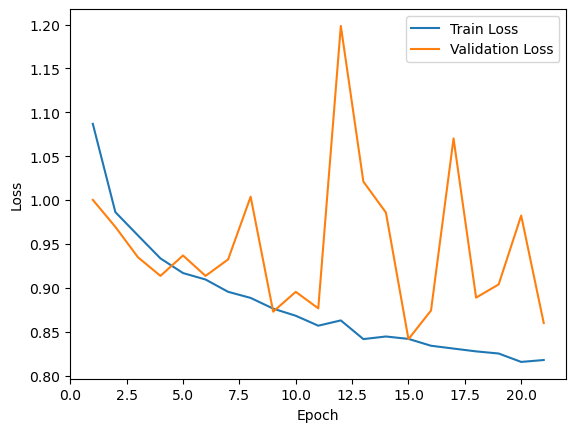

In [13]:
patience = 6
epochs_no_improve = 0
num_epochs = 30 

"""
Considering the learning rate, I would normally train more epochs. However, due to limits in processing power I have opted for just 30. 
A higher learning rate wouldn't work as it leads to issues due to requiring far stricter restrictions on patience to prevent overfitting 
considering the limited number of epochs. This may result in preemptive loop breaking and underfitting.
"""

min_valid_loss = float('inf')
train_losses = []
val_losses = []
epochs = []

plt.figure()

if __name__ == "__main__":
    for epoch in tqdm.tqdm(range(num_epochs)):
        model.train()
        train_loss = 0
        
        for img, label in train_loader:
            img = img.to(device)
            label = label.to(device)
            pred = model(img)
            loss = criterion(pred, label)
    
            #backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        valid_loss = 0.0
        model.eval()

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                label = label.to(device)
                target = model(img)
                loss = criterion(target, label)
                valid_loss += loss.item()

            valid_loss /= len(val_loader)
            val_losses.append(valid_loss)
            epochs.append(epoch+1)
    
            print(f'Epoch {epoch+1} \t\t Training Loss: {train_loss} \t\t Validation Loss: {valid_loss}')
    
            if valid_loss < min_valid_loss:
                print(f'Validation Loss Decreased({min_valid_loss:.6f}--->{valid_loss:.6f})')
                min_valid_loss = valid_loss
                torch.save(model.state_dict(), 'saved_model.pth')
                epochs_no_improve = 0
                
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
                    
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig("Loss_Plots.svg")

## Testing Accuracy

In [25]:
model.load_state_dict(torch.load('saved_model.pth'))
model.eval()

correct = 0
total = 0

In [27]:
if __name__ == "__main__":
    with torch.no_grad():
        for img, label in test_loader:
            img = img.to(device)
            label = label.to(device)
            output = model(img)
            
            preds = torch.argmax(output, 1) 
            
            correct += (preds == label).sum().item()
            total += label.size(0)
accuracy = correct / total
print(f"Test accuracy percentage: {accuracy * 100:.2f}%")

Test accuracy percentage: 51.84%


# Implementing Grad-CAM

In [29]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
            
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
    
        self.model.zero_grad()
        output[:, class_idx].backward()
    
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
    
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
    
        cam -= cam.min()
        cam /= cam.max() + 1e-8
    
        return cam

In [31]:
import cv2

def show_cam_on_image(img, cam):
    cam = cam.squeeze().cpu().numpy()
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = heatmap * 0.4 + img * 255

    plt.imshow(overlay.astype(np.uint8))
    plt.axis("off")

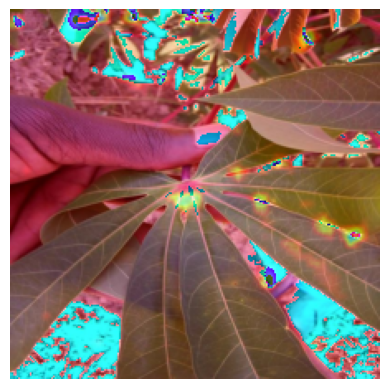

In [33]:
target_layer = model.conv_block[8]

model.eval()
gradcam = GradCAM(model, target_layer)

img, label = next(iter(val_loader))
img = img.to(device)

cam = gradcam.generate(img[:1])

show_cam_on_image(
    img[0].permute(1,2,0).cpu().numpy(),
    cam
)